# Đánh giá (Benchmark) các Mô hình Hồi quy Gradient Boosting để Dự đoán Doanh thu

Quy trình nghiên cứu học máy chuyên nghiệp:
1. **Chạy thử nghiệm (Benchmark):** Sử dụng dữ liệu hiện có để huấn luyện nhiều mô hình Gradient Boosting mạnh mẽ khác nhau (XGBoost, LightGBM, CatBoost, HistGradientBoosting).
2. **So sánh chỉ số:** Đánh giá sai số (MAE, RMSE) và độ chính xác ($R^2$ Score) cùng hiệu năng thời gian (Fit Time, Predict Time).
3. **Chọn mô hình tốt nhất:** Xác định mô hình có hiệu năng cao nhất để làm mô hình chủ đạo.
4. **Quay lại tối ưu hóa tiền xử lý (Preprocessing Alignment):** Tinh chỉnh các bước làm sạch dữ liệu, xử lý nhiễu/phân phối lệch cụ thể cho mô hình đã chọn để đạt hiệu quả tối ưu nhất.

## 1. Khai báo Thư viện và Các hàm Đánh giá

In [1]:
import numpy as np
import pandas as pd
import joblib
import time
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình trực quan hóa
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Tự cài đặt các độ đo đánh giá hồi quy từ đầu
def compute_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def compute_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def compute_rmse(y_true, y_pred):
    return np.sqrt(compute_mse(y_true, y_pred))

def compute_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - (ss_res / ss_tot) if ss_tot > 0 else 0.0

## 2. Nạp dữ liệu Đặc trưng đã chuẩn bị sẵn

In [2]:
# Tự động phát hiện thư mục chạy để tránh lỗi đường dẫn trong VS Code / Jupyter
path_prefix = './practice_2/' if os.path.exists('./practice_2/') else './'

# Load dữ liệu đặc trưng đã chuẩn bị sẵn
X_train = joblib.load(f"{path_prefix}data/ready_for_train/X_train.pkl")
X_test = joblib.load(f"{path_prefix}data/ready_for_train/X_test.pkl")
y_train = joblib.load(f"{path_prefix}data/ready_for_train/y_train.pkl")
y_test = joblib.load(f"{path_prefix}data/ready_for_train/y_test.pkl")

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test:  {X_test.shape}")

Kích thước tập Train: (78789, 44)
Kích thước tập Test:  (19698, 44)


## 3. Khai báo các mô hình Gradient Boosting tham gia thử nghiệm

In [3]:
from sklearn.ensemble import HistGradientBoostingRegressor
import warnings
warnings.filterwarnings('ignore')

# Danh sách các mô hình chạy benchmark
models = {
    "HistGradientBoosting (Sklearn)": HistGradientBoostingRegressor(random_state=42)
}

# Thử import các thư viện Gradient Boosting chuyên dụng khác
try:
    from xgboost import XGBRegressor
    models["XGBoost Regressor"] = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    print("XGBoost: Import thành công!")
except ImportError:
    print("XGBoost: Chưa được cài đặt trong môi trường này.")

try:
    from lightgbm import LGBMRegressor
    models["LightGBM Regressor"] = LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
    print("LightGBM: Import thành công!")
except ImportError:
    print("LightGBM: Chưa được cài đặt trong môi trường này.")

try:
    from catboost import CatBoostRegressor
    models["CatBoost Regressor"] = CatBoostRegressor(iterations=100, random_seed=42, verbose=0)
    print("CatBoost: Import thành công!")
except ImportError:
    print("CatBoost: Chưa được cài đặt trong môi trường này.")

XGBoost: Import thành công!
LightGBM: Import thành công!


CatBoost: Import thành công!


## 4. Thực thi quy trình Huấn luyện & Đánh giá (Benchmark Loop)

In [4]:
benchmark_results = []

for name, model in models.items():
    print(f"Đang huấn luyện mô hình: {name}...")
    
    # 1. Đo thời gian huấn luyện
    start_time = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start_time
    
    # 2. Đo thời gian dự đoán
    start_time = time.time()
    y_pred = model.predict(X_test)
    predict_time = time.time() - start_time
    
    # 3. Tính toán các chỉ số
    mae = compute_mae(y_test.values, y_pred)
    rmse = compute_rmse(y_test.values, y_pred)
    r2 = compute_r2(y_test.values, y_pred)
    
    benchmark_results.append({
        "Mô hình (Model)": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
        "Fit Time (ms)": fit_time * 1000,
        "Predict Time (ms)": predict_time * 1000
    })

# Tạo bảng kết quả DataFrame
df_results = pd.DataFrame(benchmark_results)

Đang huấn luyện mô hình: HistGradientBoosting (Sklearn)...


Đang huấn luyện mô hình: XGBoost Regressor...


Đang huấn luyện mô hình: LightGBM Regressor...


Đang huấn luyện mô hình: CatBoost Regressor...


## 5. Bảng so sánh Kết quả Tổng hợp

In [5]:
print("=== KẾT QUẢ CHẠY BENCHMARK CÁC MÔ HÌNH GRADIENT BOOSTING ===")
df_results_sorted = df_results.sort_values(by="R2 Score", ascending=False)
print(df_results_sorted.to_string(index=False))

=== KẾT QUẢ CHẠY BENCHMARK CÁC MÔ HÌNH GRADIENT BOOSTING ===
               Mô hình (Model)         MAE        RMSE  R2 Score  Fit Time (ms)  Predict Time (ms)
HistGradientBoosting (Sklearn) 1751.368964 3072.059813  0.484991     932.540894          19.749880
            LightGBM Regressor 1748.124788 3078.363744  0.482875     347.710133          12.511015
            CatBoost Regressor 1772.318555 3117.799423  0.469541     423.646927           2.662182
             XGBoost Regressor 1787.856069 3165.094866  0.453325     342.593670           7.239103


## 6. Trực quan hóa So sánh Hiệu năng

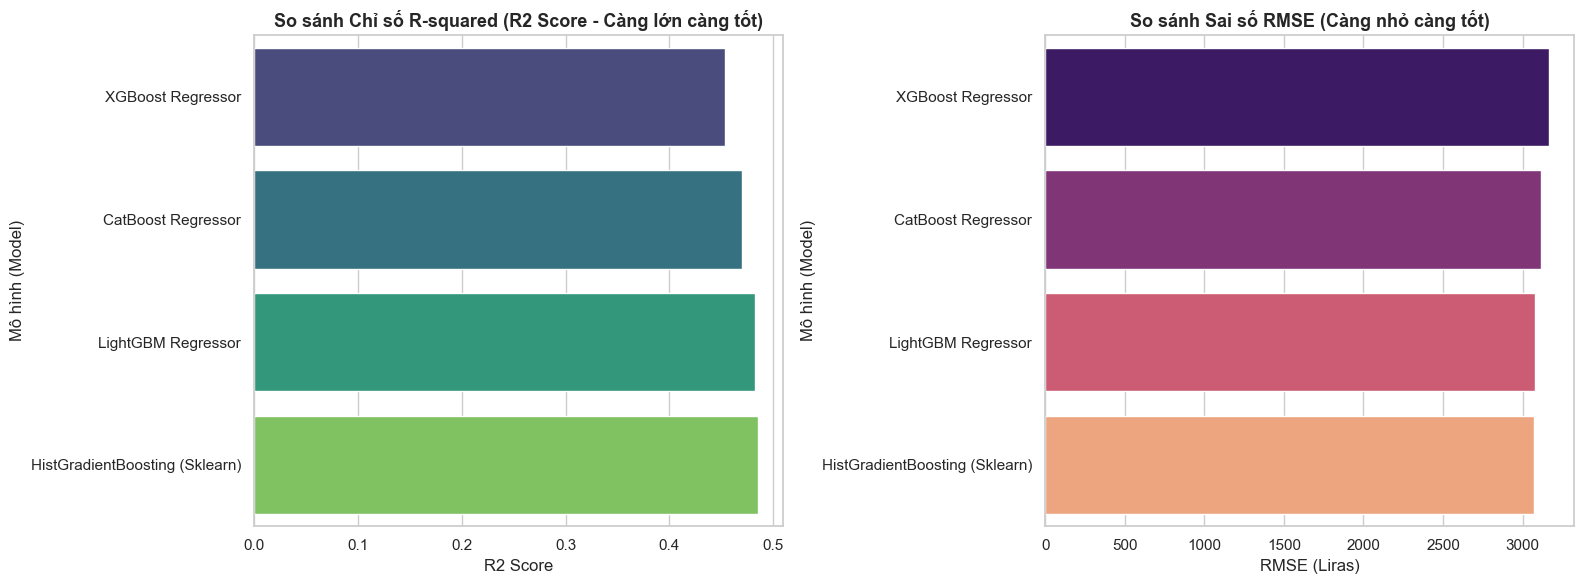

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sắp xếp kết quả để vẽ đồ thị đẹp hơn
df_sorted_r2 = df_results.sort_values(by="R2 Score", ascending=True)
sns.barplot(data=df_sorted_r2, x="R2 Score", y="Mô hình (Model)", ax=axes[0], palette="viridis")
axes[0].set_title("So sánh Chỉ số R-squared (R2 Score - Càng lớn càng tốt)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("R2 Score")

df_sorted_rmse = df_results.sort_values(by="RMSE", ascending=False)
sns.barplot(data=df_sorted_rmse, x="RMSE", y="Mô hình (Model)", ax=axes[1], palette="magma")
axes[1].set_title("So sánh Sai số RMSE (Càng nhỏ càng tốt)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("RMSE (Liras)")

plt.tight_layout()
plt.show()

## 7. Kế hoạch tối ưu hóa tiền xử lý dữ liệu sau Benchmark (Preprocessing Alignment)

Sau khi chọn được mô hình Gradient Boosting chiến thắng từ bảng đánh giá trên, chúng ta sẽ thực hiện **quay lại bước tiền xử lý (Preprocessing)** để tối ưu hóa dữ liệu dành riêng cho thuật toán đó:

### 1. Tối ưu hóa biến phân loại (Categorical Features):
*   Nếu **LightGBM** hoặc **CatBoost** đạt kết quả cao nhất: Chúng có hỗ trợ xử lý cột chữ nguyên bản cực tốt mà không cần One-Hot Encoding. Chúng ta sẽ điều chỉnh file tiền xử lý để giữ nguyên các cột chữ dạng `category` thay vì bóc tách One-Hot, giúp mô hình giữ được cấu trúc phân nhóm gốc và tăng tốc độ huấn luyện.

### 2. Xử lý lệch phân phối bằng phép biến đổi Logarit (Log Transformation):
*   Do biến mục tiêu `Sales_Revenue` có độ lệch phải (skewed) rất cao với một vài giao dịch siêu khủng. Các thuật toán Boosting có thể học tốt hơn nếu ta biến đổi logarit cho biến mục tiêu trước khi train:
    $$y_{\text{log}} = \log(y + 1)$$
*   Sau khi dự đoán, ta sẽ mũ hóa ngược lại để tính toán sai số thực tế:
    $$\hat{y} = \exp(\hat{y}_{\text{log}}) - 1$$

### 3. Phân nhóm độ tuổi (Binning Age):
*   Thay vì để tuổi liên tục từ 18-69, ta có thể phân nhóm tuổi thành các phân khúc thế hệ (Ví dụ: Gen Z, Millennials, Gen X) vì hành vi mua sắm và khả năng tài chính thường đi theo các mốc thế hệ xã hội, giúp mô hình phân nhánh cây hiệu quả hơn.